In [1]:
!pip install --upgrade pip
!pip install wandb --upgrade
!pip install transformers sentencepiece evaluate jiwer
!pip install peft -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 8.6 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: pip
    Found existing installation: pip 23.1.2
    Uninstalling pip-23.1.2:
      Successfully uninstalled pip-23.1.2
  Obtaining dependency information for wandb from https://files.pythonhosted.org/packages/ed/d7/8927aef63869d5d379adb63dc97f9cbc53830fdf85457b84a156fabcb231/wandb-0.15.8-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 22.8 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: wandb
    Found existing installation: wandb 0.15.5
    Uninstalling wandb-0.15.5:
      Successfully uninstalled wandb-0.15.5
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.4/81.4 kB 3.3 MB/s eta 0:00:00
  Obtaining dependency information for jiwer from https://files.pythonhosted.org/packages/23/a3/92c29a5e422acd87e3b4f2e6dc0ce877070cc9b2f81d30fe84122032338a/jiwer-3.0.2-py3-none-any.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 33.

In [2]:
def extract_all_chars(batch):
    all_text = " ".join(batch)
    vocab = list(set(all_text))
    return vocab

In [3]:
import re

def remove_special_characters(batch):
    chars_to_ignore_regex = '[\,\?\.\!\-\;\:\"\—\‘\'\‚\“\”\…]'
    batch = re.sub(chars_to_ignore_regex, '', batch) + " "
    return batch

In [4]:
import numpy as np
import pandas as pd
import os
import json
os.makedirs("data", exist_ok=True)

df = pd.read_csv('/kaggle/input/bengaliai-speech/train.csv')
df['sentence'] = df['sentence'].apply(remove_special_characters,)
train_df = df[df['split'] == 'train'][['id', 'sentence']].sample(frac = 1, ).reset_index(drop=True).iloc[:100000].reset_index(drop=True)
val_df   = df[df['split'] == 'valid'][['id', 'sentence']].sample(frac = 1).reset_index(drop=True).iloc[:2000].reset_index(drop=True)
new_train = {'id': [], 'sentence': []}
train_valu = train_df.values
for i in range(0, len(train_valu), 2):
    new_id = f'{train_valu[i][0]}|||{train_valu[i+1][0]}'
    new_sent = train_valu[i][1] + ' ' + train_valu[i+1][1]
    new_train['id'].append(new_id)
    new_train['sentence'].append(new_sent)
    
new_train = pd.DataFrame().from_records(new_train)

new_val = {'id': [], 'sentence': []}
val_valu = val_df.values
for i in range(0, len(val_valu), 2):
    new_id = f'{val_valu[i][0]}|||{val_valu[i+1][0]}'
    new_sent = val_valu[i][1] + ' ' + val_valu[i+1][1]
    new_val['id'].append(new_id)
    new_val['sentence'].append(new_sent)
    
new_val = pd.DataFrame().from_records(new_val)

NUM_OF_ROWS = new_train.shape[0]
new_train.to_csv('data/train.csv', index=False)
new_val.to_csv('data/valid.csv', index=False)


del df, train_df, val_df, train_valu, new_train, new_val, val_valu

Number of rows 50000


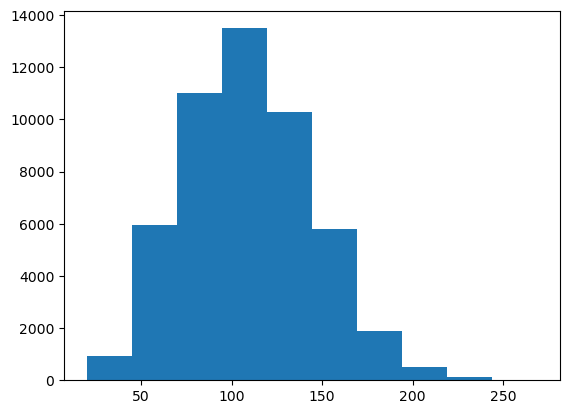

In [5]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import re

def remove_special_characters(batch):
    chars_to_ignore_regex = '[\,\?\.\!\-\;\:\"\—\‘\'\‚\“\”\…]'
    batch = re.sub(chars_to_ignore_regex, '', batch) + " "
    return batch

df = pd.read_csv('data/train.csv')[['id', 'sentence']]
df['sentence'] = df['sentence'].apply(remove_special_characters,)
vocab = extract_all_chars(df.sentence.values.tolist())
vocab_dict = {v: k for k, v in enumerate(vocab)}
vocab_dict['<pad>'] = len(vocab_dict)
vocab_dict['<unk>'] = len(vocab_dict)
vocab_dict["|"] = vocab_dict[" "]
del vocab_dict[" "]
a = [(k, v) for k,v in vocab_dict.items() if v == 0][0]
b = ('|', vocab_dict.get('|'))
vocab_dict[a[0]] = b[1]
vocab_dict[b[0]] = a[1]
with open('vocab.json', 'w') as vocab_file:
    json.dump(vocab_dict, vocab_file)

print('Number of rows', len(df))
lens = []
for row in df.values:
    lens.append(len(row[1]))
    

plt.hist(lens)
plt.show()

In [6]:
# import os
# import json
# from transformers import Wav2Vec2CTCTokenizer, Wav2Vec2FeatureExtractor, Wav2Vec2Processor

# model_id = 'Wav2Vec-xlsr-lora'

# feature_extractor = Wav2Vec2FeatureExtractor(feature_size=1, sampling_rate=16000, padding_value=0.0, do_normalize=True, return_attention_mask=True)

# tokenizer = Wav2Vec2CTCTokenizer.from_pretrained('./', unk_token="<unk>", pad_token="<pad>", word_delimiter_token="|",)

# processor = Wav2Vec2Processor(feature_extractor=feature_extractor, tokenizer=tokenizer)

# processor.save_pretrained(model_id)

# del feature_extractor, processor, Wav2Vec2CTCTokenizer, Wav2Vec2FeatureExtractor, Wav2Vec2Processor, vocab_dict

In [7]:
import librosa
import numpy as np
def numarize(batch):
    sr = 16000
    def load_mp3(file_path):
        file_paths = file_path.split('|||')
        audios = []
        for f in file_paths:
            au, _ = librosa.load(f'/kaggle/input/bengaliai-speech/train_mp3s/{f}.mp3', sr=sr)
            audios.append(au)
            audios.append(np.zeros((500,)))
        audios = np.hstack(audios)
        return audios
    
    audio = list(map(load_mp3, batch['id']))
    # batched output is "un-batched"
    inputs = {'input_values': audio}
    
    inputs["labels"] = processor(text=batch["sentence"]).input_ids

    return inputs

class DataCollatorWav2VecWithPadding:
    def __init__(self, processor, model=None, padding = True, max_length = None, max_length_labels = None,
                 pad_to_multiple_of = None, pad_to_multiple_of_labels = None, truncation=None, return_tensors='pt'):
        self.processor = processor
        self.model = model
        self.padding = padding
        self.max_length = max_length
        self.max_length_labels = max_length_labels
        self.pad_to_multiple_of = pad_to_multiple_of
        self.pad_to_multiple_of_labels = pad_to_multiple_of_labels
        self.truncation = truncation
        self.return_tensors = return_tensors
    
    def __call__(self, features, return_tensors=None):
        if return_tensors is not None:
            self.return_tensors = return_tensors

        label_name = "label" if "label" in features[0].keys() else "labels"
        labels = [{'input_ids': v for k, v in feature.items() if k == label_name} for feature in features ] if label_name in features[0].keys() else None
        no_labels_features = [v for feature in features for k, v in feature.items() if k != label_name]
        sr = 16000

        batch = self.processor.feature_extractor(no_labels_features,
                                                 sampling_rate=sr,
                                                   padding=self.padding, 
                                                   max_length=self.max_length,
                                                   truncation=self.truncation,
                                                   pad_to_multiple_of=self.pad_to_multiple_of,
                                                   return_tensors=self.return_tensors)
        if labels is not None:
            labels_batch = self.processor.tokenizer.pad(labels, 
                                         padding=self.padding,
                                         max_length=self.max_length_labels,
#                                          truncation=self.truncation,
                                         pad_to_multiple_of=self.pad_to_multiple_of_labels,
                                         return_tensors=self.return_tensors)   

        
        # replace padding with -100 to ignore loss correctly

        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)
        batch["labels"] = labels   
        
        return batch
        
        
class DataCollatorWav2txtStreaming:
    def __init__(self, processor, model=None, padding = True, max_length = None, max_length_labels = None,
                 pad_to_multiple_of = None, pad_to_multiple_of_labels = None, return_tensors='pt'):
        self.processor = processor
        self.model = model
        self.padding = padding
        self.max_length = max_length
        self.max_length_labels = max_length_labels
        self.pad_to_multiple_of = pad_to_multiple_of
        self.pad_to_multiple_of_labels = pad_to_multiple_of_labels
        self.return_tensors = return_tensors
    
    def __call__(self, features, return_tensors=None):
        if return_tensors is not None:
            self.return_tensors = return_tensors

        
        sr = 16000
        def load_mp3(file_path):
            file_paths = file_path.split('|||')
            audios = []
            for f in file_paths:
                au, _ = librosa.load(f'/kaggle/input/bengaliai-speech/train_mp3s/{f}.mp3', sr=sr)
                audios.append(au)
                audios.append(np.zeros((3000,)))
            audios = np.hstack(audios)
            return audios
        
        audio = list(map(load_mp3, features["id"]))
        # batched output is "un-batched"
        batch = self.processor.feature_extractor(audio, sampling_rate=sr, 
                                                   padding=self.padding, 
                                                   max_length=self.max_length,
                                                   pad_to_multiple_of=self.pad_to_multiple_of,
                                                   return_tensors=self.return_tensors)
        
#         batch["input_length"] = np.array([len(batch["input_values"][0])] * len(batch["input_values"]), dtype=np.int64)
        
        labels_batch = self.processor(text=features["sentence"], 
                                 padding=self.padding,
                                 max_length=self.max_length_labels,
                                 pad_to_multiple_of=self.pad_to_multiple_of_labels,
                                 return_tensors=self.return_tensors)   

        
        # replace padding with -100 to ignore loss correctly
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)

        batch["labels"] = labels
#         if self.model is not None and batch["labels"] is not None:
#             batch["decoder_input_ids"] = model.prepare_decoder_input_ids_from_labels(labels)
        

        return batch
        

https://discuss.huggingface.co/t/indexerror-invalid-key-16-is-out-of-bounds-for-size-0/14298/4

In [8]:
def print_trainable_parameters(model):
    trainable_params = 0
    all_param = 0
    for _, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    print(
        f"trainable params: {trainable_params} || all params: {all_param} || trainable%: {100 * trainable_params / all_param:.2f}"
    )

In [9]:
import torch
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor
from evaluate import load

model_id = 'Wav2Vec-xlsr-lora'
model_id = '/kaggle/input/lora-vec/best_model'
processor = Wav2Vec2Processor.from_pretrained(model_id)

model_id = 'facebook/wav2vec2-base-100k-voxpopuli'
# model_id = 'facebook/wav2vec2-xls-r-300m'
model_id = '/kaggle/input/lora-vec/model_checkpoint/checkpoint-4500'
model = Wav2Vec2ForCTC.from_pretrained(model_id, ctc_loss_reduction='mean', 
                               ctc_zero_infinity=True, ignore_mismatched_sizes=True,
                               pad_token_id=processor.tokenizer.pad_token_id, mask_time_prob=0.0005, 
                               diversity_loss_weight=70, layerdrop=0.001,
                               final_dropout=0.057,)

# model = Wav2Vec2ForCTC.from_pretrained(model_id, vocab_size=processor.tokenizer.vocab_size, hidden_act='gelu_new', ctc_loss_reduction='mean', 
#                                        ctc_zero_infinity=True, ignore_mismatched_sizes=True,
#                                        pad_token_id=processor.tokenizer.pad_token_id,
#                                        mask_time_prob=0.0005, diversity_loss_weight=70, layerdrop=0.001, final_dropout=0.05,)
# model.save_pretrained(model_id,)
model.freeze_feature_encoder()
for i, p in enumerate(model.wav2vec2.encoder.layers):
    if i < 5:
        p.requires_grad_(False)
    else:
        p.requires_grad_(True)
print_trainable_parameters(model)

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl6StatusC1EN10tensorflow5error4CodeESt17basic_string_viewIcSt11char_traitsIcEENS_14SourceLocationE']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: l

trainable params: 54788041 || all params: 94427849 || trainable%: 58.02


In [16]:
# from peft import LoraConfig, get_peft_model

# config = LoraConfig(
#                     r=128,
#                     lora_alpha=32,
#                     target_modules=["k_proj", 'v_proj', 'intermediate_dense',],
#                     lora_dropout=0.15,
#                     bias="none",
# #                     layers_to_transform=list(range(0, 24, 2)),
#                     modules_to_save=["lm_head",],)

# lora_model = get_peft_model(model, config)
# print_trainable_parameters(lora_model)


In [10]:
import os
# set the wandb project where this run will be logged
os.environ["WANDB_PROJECT"]="bngali_ASR"

# save your trained model checkpoint to wandb
os.environ["WANDB_LOG_MODEL"]="true"

# turn off watch to log faster
os.environ["WANDB_WATCH"]="True"

os.environ["WANDB_API_KEY"] = 'b8ad1673354b49d42bf0bfd9436537326dd350cc'

os.environ["WANDB_LOG_MODEL"] = 'true'

os.environ["WANDB_WATCH"] = 'all'

In [11]:
import gc
gc.collect()

171

In [12]:
from transformers import TrainingArguments, Trainer
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer
from datasets import load_dataset
from evaluate import load
import numpy as np
import wandb

In [13]:
batch_size = 20

In [14]:
train_data = load_dataset('data', split='train', streaming=False)
# train_colleter = DataCollatorWav2txtStreaming(processor, model=model, padding='longest', return_tensors='pt')

maped_train = train_data.map(numarize, remove_columns=['id', 'sentence'], batched=True, batch_size=batch_size, num_proc=2)
# maped_train = maped_train.with_format("torch")

val_data = load_dataset('data', split='validation', streaming=False)
# val_colleter = DataCollatorWav2txtWithPadding(processor, model=model, padding='longest', return_tensors='pt')
maped_val = val_data.map(numarize, remove_columns=['id', 'sentence'], batched=True, batch_size=batch_size, num_proc=2)
# maped_val = maped_val.with_format("torch")

Extracting data files:   0%|          | 0/2 [00:00<?, ?it/s]

/opt/conda/lib/python3.10/site-packages/datasets/packaged_modules/csv/csv.py:154: FutureWarning: the 'mangle_dupe_cols' keyword is deprecated and will be removed in a future version. Please take steps to stop the use of 'mangle_dupe_cols'
  csv_file_reader = pd.read_csv(file, iterator=True, dtype=dtype, **self.config.read_csv_kwargs)


Dataset csv downloaded and prepared to /root/.cache/huggingface/datasets/csv/data-d7241d1af7979f1c/0.0.0/433e0ccc46f9880962cc2b12065189766fbb2bee57a221866138fb9203c83519. Subsequent calls will reuse this data.
  

/opt/conda/lib/python3.10/site-packages/datasets/packaged_modules/csv/csv.py:154: FutureWarning: the 'mangle_dupe_cols' keyword is deprecated and will be removed in a future version. Please take steps to stop the use of 'mangle_dupe_cols'
  csv_file_reader = pd.read_csv(file, iterator=True, dtype=dtype, **self.config.read_csv_kwargs)


#0:   0%|          | 0/2084 [00:00<?, ?ba/s]

#1:   0%|          | 0/2084 [00:00<?, ?ba/s]

#0:   0%|          | 0/42 [00:00<?, ?ba/s]

#1:   0%|          | 0/42 [00:00<?, ?ba/s]

In [15]:
val_colleter = DataCollatorWav2VecWithPadding(processor, model=model, padding='longest', return_tensors='pt')

In [16]:
def train(data_size=None, batch_size=1, acc_steps=1, eval_batch_size=1, eval_acc_steps=1, epochs=1):
    
#     wandb.watch(model)
    wer = load("wer")
    def wer_metric(pred):
        pred_logits = pred.predictions

        pred_ids = np.argmax(pred_logits, axis=-1)
        
        pred.label_ids[pred.label_ids == -100] = processor.tokenizer.pad_token_id

        pred_str = processor.batch_decode(pred_ids)
        # we do not want to group tokens when computing the metrics
        label_str = processor.batch_decode(pred.label_ids, group_tokens=False,)

        wer_metric = wer.compute(predictions=pred_str, references=label_str)

        return {"wer": wer_metric}
    args = TrainingArguments(
                                output_dir='model_checkpoint',
                                do_train=True,
                                do_eval=True,
                                per_device_train_batch_size=batch_size,
                                per_device_eval_batch_size=eval_batch_size,
                                gradient_accumulation_steps=acc_steps,
                                eval_accumulation_steps=eval_acc_steps,
                                dataloader_num_workers=2,
                                learning_rate=4e-5,

#                                 max_steps = data_size // (batch_size*acc_steps),
                                adafactor=True,
                                weight_decay=0.009,
                                max_grad_norm=0.3,
                                num_train_epochs=epochs,
                                warmup_steps=100,
                                dataloader_drop_last=True,
                                save_steps=500,
                                eval_steps=100,
                                logging_steps=20,
#                                     eval_delay=500,
                                evaluation_strategy='steps',
                                logging_strategy='steps',
                                lr_scheduler_type='cosine',
                                logging_first_step=True,
                                fp16=True,
                                fp16_full_eval=False,
                                gradient_checkpointing=True,
                                save_total_limit=4,
                                load_best_model_at_end=True,
                                metric_for_best_model="wer",
                                resume_from_checkpoint=False,
                                remove_unused_columns=False,
                                label_names=['labels'],
                                run_name='ctc-wav2vec-v2',
                                report_to='wandb'
    )
    
    
    doing = Trainer(model, args, data_collator=val_colleter, 
                           train_dataset=maped_train,
                           eval_dataset=maped_val,
                           compute_metrics=wer_metric,
                           tokenizer=processor.feature_extractor
                          )
    
    train_result = doing.train(resume_from_checkpoint=False)
    trainer.evaluate()
    wandb.finish()
    return doing, train_result

In [17]:
trainer = train(data_size=None, batch_size=8, acc_steps=4, eval_batch_size=10, eval_acc_steps=10, epochs=3)

/opt/conda/lib/python3.10/site-packages/transformers/training_args.py:1324: FutureWarning: `--adafactor` is deprecated and will be removed in version 5 of 🤗 Transformers. Use `--optim adafactor` instead
  warnings.warn(
wandb: Currently logged in as: sebaeymohamed43. Use `wandb login --relogin` to force relogin


Step,Training Loss,Validation Loss,Wer
100,1.811200,1.137243,0.831745
200,1.776400,1.088663,0.805970
300,1.735100,1.039107,0.795946
400,1.737900,0.991948,0.777937
500,1.656600,0.958238,0.760864
600,1.671400,0.932393,0.751115
700,1.597400,0.900660,0.742909
800,1.577100,0.877328,0.731729
900,1.630300,0.846695,0.708762
1000,1.615100,0.844789,0.715261


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 trainer = train(data_size=None, batch_size=8, acc_steps=4, eval_batch_size=10, eval_acc_     │
│   2                                                                                              │
│                                                                                                  │
│ in train:66                                                                                      │
│                                                                                                  │
│   63 │   │   │   │   │   │      tokenizer=processor.feature_extractor                            │
│   64 │   │   │   │   │   │     )                                                                 │
│   65 │                                                                                           │
│ ❱ 66 │   train_result = doing.train(resume_from_checkpoint=False)                                │
│   67 │   trainer.evaluate()                                                                      │
│   68 │   wandb.finish()                                                                          │
│   69 │   return doing, train_result                                                              │
│                                                                                                  │
│ /opt/conda/lib/python3.10/site-packages/transformers/trainer.py:1645 in train                    │
│                                                                                                  │
│   1642 │   │   inner_training_loop = find_executable_batch_size(                                 │
│   1643 │   │   │   self._inner_training_loop, self._train_batch_size, args.auto_find_batch_size  │
│   1644 │   │   )                                                                                 │
│ ❱ 1645 │   │   return inner_training_loop(                                                       │
│   1646 │   │   │   args=args,                                                                    │
│   1647 │   │   │   resume_from_checkpoint=resume_from_checkpoint,                                │
│   1648 │   │   │   trial=trial,                                                                  │
│                                                                                                  │
│ /opt/conda/lib/python3.10/site-packages/transformers/trainer.py:1938 in _inner_training_loop     │
│                                                                                                  │
│   1935 │   │   │   │   │   self.control = self.callback_handler.on_step_begin(args, self.state,  │
│   1936 │   │   │   │                                                                             │
│   1937 │   │   │   │   with self.accelerator.accumulate(model):                                  │
│ ❱ 1938 │   │   │   │   │   tr_loss_step = self.training_step(model, inputs)                      │
│   1939 │   │   │   │                                                                             │
│   1940 │   │   │   │   if (                                                                      │
│   1941 │   │   │   │   │   args.logging_nan_inf_filter                                           │
│                                                                                                  │
│ /opt/conda/lib/python3.10/site-packages/transformers/trainer.py:2759 in training_step            │
│                                                                                                  │
│   2756 │   │   │   return loss_mb.reduce_mean().detach().to(self.args.device)                    │
│   2757 │   │                                               

In [ ]:
trainer.evaluate?

In [ ]:
trainer.save_model('best_model')
processor.save_pretrained('best_model')

In [18]:
wandb.finish()


eval/loss,█▇▇▆▆▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/runtime,▅▇█▅▂▄▄▄▃▄▂▂▃▃▃▂▃▃▄▄▅▂▃▂▃▃▂▆▄▄▄▃▂▆▁▂▂▂▃▁
eval/samples_per_second,▄▂▁▄▇▅▅▅▆▅▇▇▆▆▆▇▆▆▅▅▄▇▆▇▆▆▇▃▅▅▅▆▇▃█▆▇▇▆█
eval/steps_per_second,▄▂▁▃▇▅▅▅▆▅▇▇▆▆▆█▆▆▅▅▃▇▆▇▆▆▇▃▅▅▄▆▇▃█▆▇▇▆█
eval/wer,█▇▇▆▆▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
train/epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train/global_step,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train/learning_rate,▂████████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁
train/loss,██▇▇▆▅▅▅▅▅▄▃▄▄▄▃▃▃▃▃▂▃▂▂▂▁▂▂▁▂▁▁▂▁▂▁▂▁▂▁
eval/loss,0.6213
eval/runtime,154.9681


In [ ]:
!ls model_checkpoint/checkpoint-4500

In [ ]:
import torch
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor
from evaluate import load
wer = load("wer")
model_id = 'best_model'
processor = Wav2Vec2Processor.from_pretrained(model_id)

model_id = 'model_checkpoint/checkpoint-4500'
model = Wav2Vec2ForCTC.from_pretrained(model_id, pad_token_id=processor.tokenizer.pad_token_id,)


In [ ]:
import pandas as pd
import os
df = pd.read_csv('/kaggle/input/bengaliai-speech/train.csv')
wav_path = '/kaggle/input/bengaliai-speech/train_mp3s'
df = df[df['split'] == 'train'][['id', 'sentence']]
df['id'] = df['id'].map(lambda x: os.path.join(wav_path, f'{x}.mp3'))
df = df.values

In [ ]:
import librosa
import numpy as np

def get_script_with_wer(audio_path, label, sr=16000):
    model.cuda().eval()
    def load_mp3(file_path):
        au, _ = librosa.load(audio_path)
        return au
    audio = load_mp3(audio_path)
    audio = processor(audio, sampling_rate=sr, return_tensors='pt').input_values

    with torch.no_grad():
        logits = model(audio.cuda()).logits.cpu().numpy()
    pred_ids = np.argmax(logits, axis=-1)
    print(pred_ids)
    pred_str = processor.batch_decode(pred_ids, group_tokens=True,)[0]

    wer_err = wer.compute(predictions=[pred_str], references=[label])
    
    return {'ref': label, 'preds': pred_str, "WER": wer_err}
    
    

In [ ]:
get_script_with_wer(df[555, 0], df[555, 1])

In [ ]:
!ls model_checkpoint

In [ ]:
# ijiophp

- https://huggingface.co/Tahsin-Mayeesha/wav2vec2-bn-300m
- https://discuss.huggingface.co/t/code-review-compute-metrics-for-wer-with-wav2vec2processorwithlm/16841/5
- https://discuss.huggingface.co/t/question-about-wav2vec2/17620/2
- https://discuss.huggingface.co/t/set-sampling-rate-in-wav2vec-2-0-processor/17756
- https://discuss.huggingface.co/t/training-and-evaluation-loss-goes-down-however-wer-score-stays-the-same/18259
- https://discuss.huggingface.co/t/eliminating-pad-token-from-wav2vec2-prediction/17702/3
- https://discuss.huggingface.co/t/using-hyperparameter-search-in-trainer/785/89
- https://arxiv.org/pdf/2209.06581.pdf
- https://arxiv.org/pdf/2306.01743.pdf
